In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [3]:
two_dim = False
inputname = 'runs/9_9/H_input_2025-09-09_16-19-01.txt'
outputname=inputname.replace('input', 'output')
logname=inputname.replace('input', 'log')
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input
density_plot = False

In [4]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

In [5]:
import os
cores = os.cpu_count()
print(f"You have {cores} CPU cores.")

You have 20 CPU cores.


In [6]:
from concurrent.futures import ThreadPoolExecutor

def parse_snapshot_at_offset(filename, offset):
    """
    Parse a single snapshot starting at file byte offset.
    Returns a dict with parsed data.
    """
    with open(filename, 'r') as f:
        f.seek(offset)
        
        N = int(f.readline().strip())
        D = int(f.readline().strip())
        t = float(f.readline().strip())
        
        # Skip masses
        for _ in range(N):
            f.readline()
        
        positions = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        velocities = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        
        return {
            'N': N,
            'D': D,
            'time': t,
            'positions': np.array(positions),
            'velocities': np.array(velocities)
        }

def find_snapshot_offsets(filename):
    """
    Scan the file once to find byte offsets where each snapshot starts.
    """
    offsets = []
    with open(filename, 'r') as f:
        while True:
            pos = f.tell()
            line = f.readline()
            if not line:
                break
            # If line looks like a snapshot start (N)
            if line.strip().isdigit():
                offsets.append(pos)
                # Skip N, D, time, masses, positions, velocities to get to next snapshot
                N = int(line.strip())
                D = int(f.readline().strip())
                # 1 line for time + N for masses + N for positions + N for velocities
                to_skip = 1 + N*3
                for _ in range(to_skip):
                    f.readline()
            else:
                # If format guarantees snapshot starts with N, else ignore line
                continue
    return offsets

def parallel_parse(filename, max_workers=4):
    offsets = find_snapshot_offsets(filename)
    print(f"Found {len(offsets)} snapshots.")

    results = []
    # usa ThreadPoolExecutor invece di ProcessPoolExecutor
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(parse_snapshot_at_offset, filename, off) for off in offsets]
        for future in futures:
            results.append(future.result())

    # Check consistency
    N = results[0]['N']
    D = results[0]['D']

    times = np.array([r['time'] for r in results])
    positions = np.array([r['positions'] for r in results])  # (snapshots, N, D)
    velocities = np.array([r['velocities'] for r in results])  # (snapshots, N, D)

    # Transpose to (N, snapshots, D)
    positions = positions.transpose(1, 0, 2)
    velocities = velocities.transpose(1, 0, 2)

    return N, D, len(results), times, positions, velocities


In [7]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

if input_plot:
    fig = plt.figure()
    if (two_dim == True):
        ax = fig.add_subplot()
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], color = 'b')
        ax.set(xlabel = 'x', ylabel = 'y', title = str(n_particles) + ' particles')
    else:
        ax = fig.add_subplot(projection='3d')
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], init_p[i][2], color = 'b', s = 1)
        ax.set(xlabel = 'x', ylabel = 'y', zlabel = 'z', title = str(n_particles) + ' particles')

    plt.show()

In [8]:
if __name__ == '__main__':
    filename = outputname
    N, n_dim, snap_number, time, positions, velocities = parallel_parse(filename, max_workers=cores-2)

Found 469 snapshots.


In [9]:
print(f"Loaded {snap_number} snapshots with {N} particles and {n_dim} dimensions.")

Loaded 469 snapshots with 30002 particles and 3 dimensions.


### Saving CoM

In [10]:
r_CM_tot_0 = np.sum(mass[:, None] * positions[:,0,:], axis=0) / np.sum(mass)
v_CM_tot_0 = np.sum(mass[:, None] * velocities[:,0,:], axis=0) / np.sum(mass)

print("CoM position at t = 0:", r_CM_tot_0)
print("CoM velocity at t = 0:", v_CM_tot_0)

CoM position at t = 0: [6.32049242e-08 1.44773830e-07 2.46996792e-08]
CoM velocity at t = 0: [-1.27037265e-12 -1.46027615e-10  1.04790373e-10]


In [30]:
x_CM = []
y_CM = []
z_CM = []

vx_CM = []
vy_CM = []
vz_CM = []

for i in range(snap_number):
    x_CM.append(np.sum(mass * positions[:, i, 0]) /np.sum(mass))
    y_CM.append(np.sum(mass * positions[:, i, 1]) /np.sum(mass))
    z_CM.append(np.sum(mass * positions[:, i, 2]) /np.sum(mass))

    vx_CM.append(np.sum(mass * velocities[:, i, 0]) /np.sum(mass))
    vy_CM.append(np.sum(mass * velocities[:, i, 1]) /np.sum(mass))
    vz_CM.append(np.sum(mass * velocities[:, i, 2]) /np.sum(mass))

r_CM = np.array([x_CM, y_CM, z_CM])
r_CM = r_CM.transpose(1, 0)

v_CM = np.array([vx_CM, vy_CM, vz_CM])
v_CM = v_CM.transpose(1, 0)

positions_shifted  = positions  - r_CM[None, :, :]
velocities_shifted = velocities - v_CM[None, :, :]

r_CM_new = np.sum(mass[:, None, None] * positions_shifted, axis=0) / np.sum(mass)
v_CM_new = np.sum(mass[:, None, None] * velocities_shifted, axis=0) / np.sum(mass)


print("In CoM reference frame:\nCoM max position:", np.max(np.abs(r_CM_new)), "\tCoM max velocity:", np.max(np.abs(v_CM_new)))
print('BH_1 position: ', positions_shifted[0,0,:], '\t BH_2 position: ', positions_shifted[1,0,:])

In CoM reference frame:
CoM max position: 5.6003368335771425e-14 	CoM max velocity: 3.228937579558483e-17
BH_1 position:  [10.00028294  2.43277486 -3.64352392] 	 BH_2 position:  [-1.99971716  2.43277486 -3.64352392]


In [38]:
positions = positions_shifted
velocities = velocities_shifted

### Saving BH quantities

In [39]:
pos_BH_1 = positions[0, :, :]
pos_BH_2 = positions[1, :, :]

BH_distance = 0.0
for i in range(3): BH_distance += (pos_BH_1[:, i] - pos_BH_2[:, i])**2

BH_distance = np.sqrt(BH_distance)

In [40]:
vel_BH_1 = velocities[0, :, :]
vel_BH_2 = velocities[1, :, :]

v_1 = np.sqrt(vel_BH_1[:, 0]**2 +  vel_BH_1[:, 1]**2 + vel_BH_1[:, 2]**2) #module of BH_1's velocity
v_2 = np.sqrt(vel_BH_2[:, 0]**2 +  vel_BH_2[:, 1]**2 + vel_BH_2[:, 2]**2)

### Computing radial quantities

In [41]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

radius_at_t = []
for i in range(len(time)): radius_at_t.append(np.sqrt(positions[:, i, 0]**2 + positions[:, i, 1]**2 + positions[:, i, 2]**2))
radius_at_t = np.array(radius_at_t)

In [42]:
radial_v = []
for i in range(n_particles): radial_v.append((positions[i, :, 0]*velocities[i, :, 0] + positions[i, :, 1]*velocities[i, :, 1] + positions[i, :, 2]*velocities[i, :, 2])/radius[i, :])
radial_v = np.array(radial_v)

#plt.plot(time, radial_v[0])
#plt.ylabel('radial velocity')
#plt.xlabel('time')

### System mp4

In [43]:
gifname=outputname.replace('output_', '')
gifname=gifname.replace('txt', 'mp4')
print(gifname)

runs/9_9/H_2025-09-09_16-19-01.mp4


In [44]:
print(positions[0, 0, 0])

10.000282936795092


starting animation


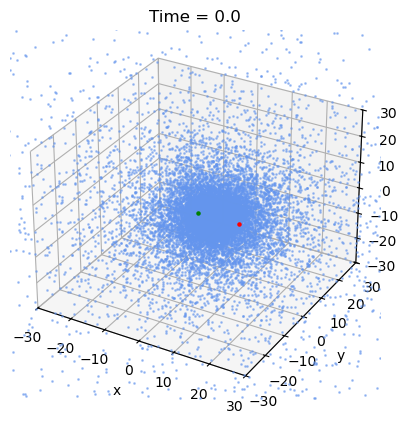

In [45]:
import matplotlib.animation as animation

fig = plt.figure()
ax = fig.add_subplot(projection='3d', computed_zorder=False)
ax.set_aspect('auto')
ax.set(xlim = [-30.0, 30.0], ylim = [-30.0, 30.0], zlim = [-30.0, 30.0], xlabel='x', ylabel='y', zlabel = 'z')

scatter_BH_1 = ax.scatter([positions[0, 0, 0]], [positions[0, 0, 1]], [positions[0, 0, 2]],
                           color='red', edgecolors='red', s=5, zorder=1)
scatter_BH_2 = ax.scatter([positions[1, 0, 0]], [positions[1, 0, 1]], [positions[1, 0, 2]],
                            color='green', edgecolors='green', s=5, zorder=1)
scatters, = ax.plot(positions[:, 0, 0], positions[:, 0, 1], positions[:, 0, 2], 'o', color='cornflowerblue', markersize = '1', alpha = 0.5, zorder=0)

print('starting animation')
  
def update(frame):
    scatters.set_data(positions[:, frame, 0], positions[:, frame, 1]) 
    scatters.set_3d_properties(positions[:, frame, 2])
    
    scatter_BH_1._offsets3d = ([positions[0, frame, 0]],
                           [positions[0, frame, 1]],
                           [positions[0, frame, 2]])

    scatter_BH_2._offsets3d = ([positions[1, frame, 0]],
                           [positions[1, frame, 1]],
                           [positions[1, frame, 2]])
    
    ax.set_title('Time = %.1f'%(time[frame]))

    return scatters, scatter_BH_1, scatter_BH_2
    
ani = animation.FuncAnimation(fig, update, snap_number, interval=100)

#ani.save(gifname, fps = 20, writer = 'ffmpeg')
ani.save(gifname, writer = animation.FFMpegWriter())

### System Energy

In [46]:
#Get the total energies from the log file, in the CM frame
def GetEnergy(filename, N):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U

    E = []
    K = []
    U = []
    t = []
    
    for i in idx:
        t.append(float(output[i+1].split()[0]))
        E.append(float(output[i + 1].split()[1]))
        K.append(float(output[i + 1].split()[2]))
        U.append(-float(output[i + 1].split()[3][:7]))
        
    #K = (np.array(K) - K_CM) * M_sun / v_iu_cgs**2
    #U = np.array(U) * G_p * 
    #E = np.add(K, U)

    file_output.close()
    return t, E, K, U

In [47]:
time_E, E, K, U = GetEnergy(logname, n_particles)

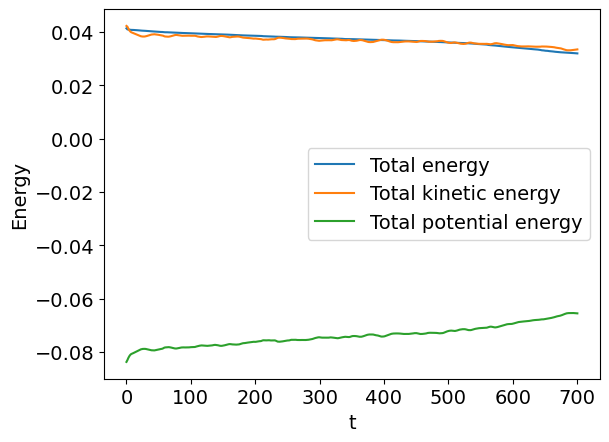

In [48]:
#plot of the energy

plt.plot(time_E, E, label="Total energy")
plt.plot(time_E, K, label="Total kinetic energy")
plt.plot(time_E, U, label="Total potential energy")
plt.xlabel("t", fontsize = 14)
plt.ylabel("Energy", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

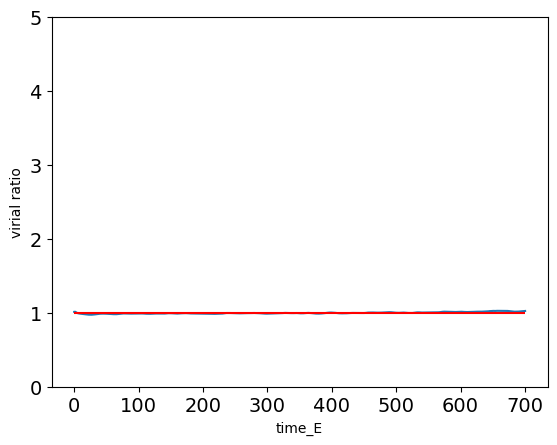

In [49]:
virial_ratio = []
for t in range(len(time_E)):
    virial_ratio.append(2 * K[t] / ( - U[t]))

plt.plot(time_E, virial_ratio)
plt.hlines(1.0, 0, max(time_E), color = 'r')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('time_E')
plt.ylabel('virial ratio')
plt.ylim(0, 5)
plt.show()

In [50]:
print(2 * K[0] / np.abs(U[0]))

1.0107475519465012


### Lagrangian radii

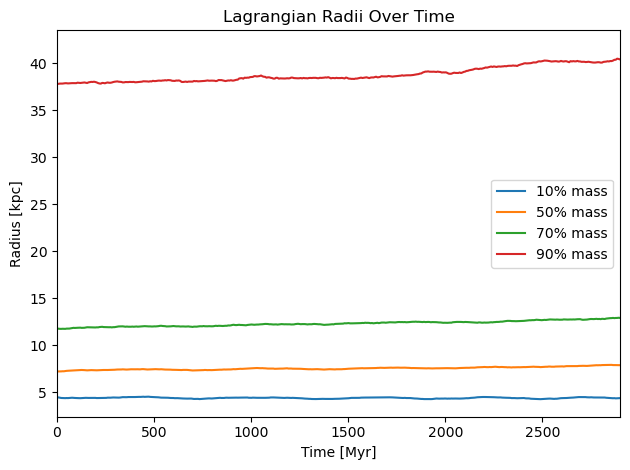

In [51]:
#compute Lagrangian radii enclosing specified mass fractions
def lagrangian_radii(pos, mass_fractions=[0.1, 0.5, 0.7, 0.9]):
    r = np.linalg.norm(pos, axis=1)  #radial distances
    r_sorted = np.sort(r)
    idxs = (np.array(mass_fractions) * len(r)).astype(int)  #indices for percentiles
    return r_sorted[idxs]

#lagrangian Radii over time
r_lag_all = []
for snap in range(snap_number):
    pos_snap = positions[:, snap, :]
    r_lag = lagrangian_radii(pos_snap)
    r_lag_all.append(r_lag)

r_lag_all = np.array(r_lag_all)

plt.figure()
for i, frac in enumerate([10, 50, 70, 90]):
    plt.plot(time*4.714829951118732, r_lag_all[:, i], label=f"{frac}% mass")

plt.xlabel("Time [Myr]")
plt.ylabel("Radius [kpc]")
plt.title("Lagrangian Radii Over Time")
plt.xlim(0, 2900)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

### BH separation

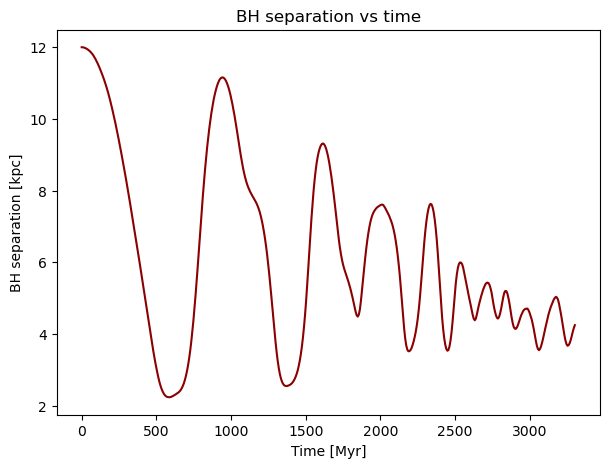

In [52]:
#dist separation bw bhs
#estrarre posizioni bhs a diversi snapshot 
pos_BH_1 = positions[0, :, :]
pos_BH_2 = positions[1, :, :]

time = np.array(time, dtype=float)

#conversione IU -> Myr 
conv_factor = 4.714829951118732  
time_Myr = time * conv_factor


BH_distance = 0.0
for i in range(3):
    BH_distance += (pos_BH_1[:, i] - pos_BH_2[:, i])**2

BH_distance = np.sqrt(BH_distance)

plt.figure(figsize=(7,5))
plt.plot(time_Myr, BH_distance, color='darkred')
plt.xlabel("Time [Myr]")   #da convertire da IU
plt.ylabel("BH separation [kpc]") #gia convertito perche 1 IU = 1 Kpc
#plt.ylim(0.2, 0.4)
plt.title("BH separation vs time")
plt.show()

In [54]:
#conversioni
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732  
#softening usato nel treecode
soft_pair = 0.06 # kpc

### Binding Energy

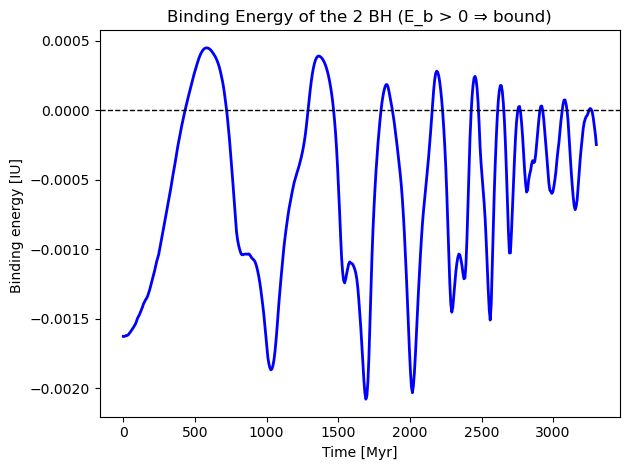

In [55]:
#masse BH
m1 = 0.1
m2 = 0.01
M_BH_tot = m1 + m2
mu = m1*m2/M_BH_tot
#potenziale Hernquist Phi(r) = - G M_host / (r + a)
M_host = 1
a_h   = 2.0        


r1 = np.asarray(positions[0], dtype=float)
r2 = np.asarray(positions[1], dtype=float) 
v1 = np.asarray(velocities[0], dtype=float)
v2 = np.asarray(velocities[1], dtype=float) 


dr = r2 - r1                   
dv = v2 - v1
r  = np.linalg.norm(dr, axis=1) #separazione (linag calcola la norma euclidea di ciascun vettore su ogni riga)
v2_rel = np.sum(dv*dv, axis=1)  #|v_rel|^2

#G=1

#energia orbitale
E_pair = 0.5*mu*v2_rel - m1*m2/np.sqrt(r**2 + soft_pair**2)  # <0 => bound

#binding energy positiva se bound
E_binding = -E_pair


plt.figure()
plt.plot(time_Myr, E_binding, lw=2, color="blue")
plt.axhline(0, ls="--", lw=1, color="black")
plt.xlabel("Time [Myr]")
plt.ylabel("Binding energy [IU] ")
plt.title("Binding Energy of the 2 BH (E_b > 0 ⇒ bound)")
plt.tight_layout()
plt.show()

### 2D orbit

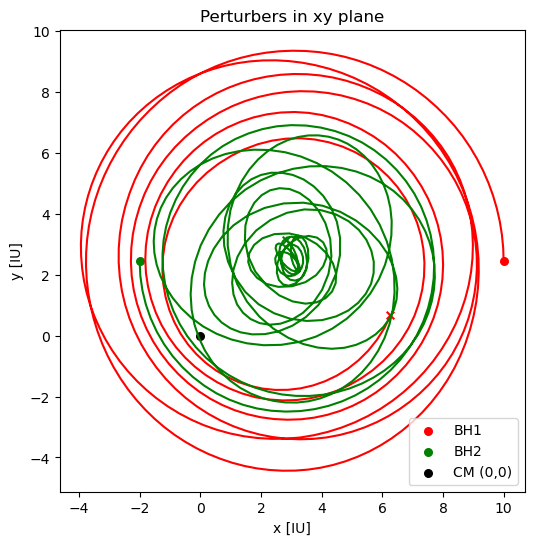

M_1 =  0.01 	M_2 =  0.005


In [71]:
#coordinate dei due BH
x1, y1 = pos_BH_1[:, 0], pos_BH_1[:, 1]
x2, y2 = pos_BH_2[:, 0], pos_BH_2[:, 1]

plt.figure(figsize=(6,6))

#BH1 
plt.plot(x1, y1, color="red")
plt.scatter([x1[0]], [y1[0]], color="red", s=30, marker="o", label="BH1")
plt.scatter([x1[-1]], [y1[-1]], color="red", s=30, marker="x")

#BH2 
plt.plot(x2, y2, color="green")
plt.scatter([x2[0]], [y2[0]], color="green", s=30, marker="o", label="BH2")
plt.scatter([x2[-1]], [y2[-1]], color="green", s=30, marker="x")

plt.plot(r_CM_new[:,0], r_CM_new[:,1], 'k--', lw=1) 
plt.scatter([0], [0], c='black', marker='o', s=30, label="CM (0,0)")

plt.xlabel("x [IU]")
plt.ylabel("y [IU]")
plt.title("Perturbers in xy plane")
plt.legend()
plt.axis("equal")  #per avere scale uguali su x e y
plt.show()

print('M_1 = ', mass[0], '\tM_2 = ', mass[1])

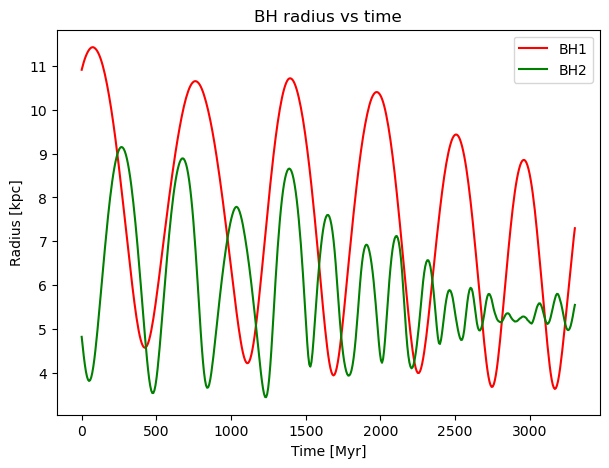

In [72]:
plt.figure(figsize=(7,5))
plt.plot(time_Myr, radius[0], label="BH1", color='red')
plt.plot(time_Myr, radius[1], label="BH2", color='green')
plt.xlabel("Time [Myr]")
plt.ylabel("Radius [kpc]")  # 1 IU = 1 kpc
plt.title("BH radius vs time")
plt.legend()
plt.show()

### R_influence

Dispersione di velocità sigma = 0.2041241452319315 IU 42.332598107311064 km/s
R_influence BH1 = 2.4000000000000004 kpc
R_influence BH2 = 0.24000000000000002 kpc
Inizio interazione a t = 110.7142 , In Myr a t = 521.9986261741495


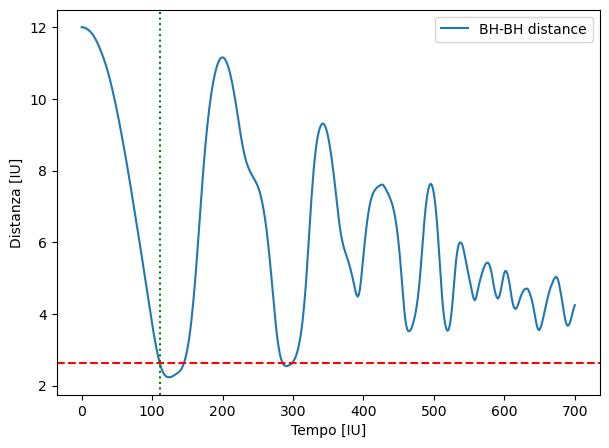

In [59]:
G = 1 #IU
M = 1  #massa totale (IU)
a = 2.0    #raggio di scala (IU)

#stima dispersione velocità (da paper per Hernquist)
sigma2 = G * M / (12 * a)
sigma = np.sqrt(sigma2)
print("Dispersione di velocità sigma =", sigma, "IU", sigma*KMS_PER_IU, "km/s")

#raggio di influenza
def r_influence(M_BH):
    return G * M_BH / (sigma**2)

r_inf1 = r_influence(M_BH1)
r_inf2 = r_influence(M_BH2)
r_sum = r_inf1 + r_inf2

print("R_influence BH1 =", r_inf1, "kpc")
print("R_influence BH2 =", r_inf2, "kpc")

#distanza tra i due BH in ogni snapshot
r12 = np.linalg.norm(pos_BH_1 - pos_BH_2, axis=1)

#trovo lo snapshot in cui r12<r_sum
snap_interaction = None
time_interaction = None
for i in range(len(r12)):
    if r12[i] <= r_sum:
        snap_interaction = i
        time_interaction = time[i]   
        print("Inizio interazione a t =", time_interaction, ", In Myr a t =", time_interaction*MYR_PER_IU)
        break

plt.figure(figsize=(7,5))
plt.plot(time, r12, label="BH-BH distance") 
plt.axhline(r_sum, color="red", linestyle="--")

if snap_interaction is not None:
    plt.axvline(time_interaction, color="green", linestyle=":")

plt.xlabel("Tempo [IU]")  
plt.ylabel("Distanza [IU]") 
plt.legend()
plt.show()

### Angular momentum

In [63]:
r_rel_1 = pos_BH_1 - r_CM
v_rel_1 = vel_BH_1 - v_CM

L_BH_rel_1 = mass[0] * np.cross(r_rel_1, v_rel_1)
L_BH_rel_1 = np.sqrt(L_BH_rel_1[:, 0]**2 + L_BH_rel_1[:, 1]**2 + L_BH_rel_1[:, 2]**2) #modulo rispetto al centro di massa

In [64]:
r_rel_2 = pos_BH_2 - r_CM
v_rel_2 = vel_BH_2 - v_CM

L_BH_rel_2 = mass[0] * np.cross(r_rel_2, v_rel_2)
L_BH_rel_2 = np.sqrt(L_BH_rel_2[:, 0]**2 + L_BH_rel_2[:, 1]**2 + L_BH_rel_2[:, 2]**2) #modulo rispetto al centro di massa

[Text(0.5, 0, 'time [Myr]'), Text(0, 0.5, 'relative angular momentum of BH_2')]

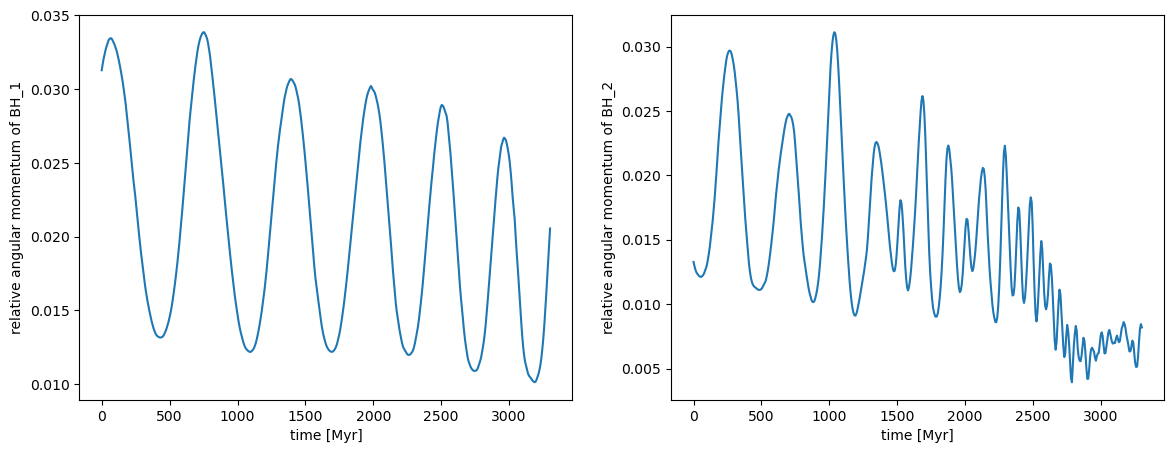

In [66]:
fig, ax, = plt.subplots(ncols = 2, nrows = 1, figsize = (14,5))
ax[0].plot(time_Myr, L_BH_rel_1)
ax[0].set(xlabel = 'time [Myr]', ylabel = 'relative angular momentum of BH_1')

ax[1].plot(time_Myr, L_BH_rel_2)
ax[1].set(xlabel = 'time [Myr]', ylabel = 'relative angular momentum of BH_2')

### Escaped particles

In [67]:
M_H = 1.0
a = 2.0
r_escape = r_lag_all[0, -1]

def v_escape (radius):
    return np.sqrt(2*M_H / (radius + a))

n_escape = 0.0
mask_escape = []

for i in tqdm(range(2, n_particles)):
    for j in range(snap_number):
        if radius[i, j] > r_escape and radial_v[i, j] >= v_escape(r_escape):
            #print('particle number ', i, f'escaped at time {time[j]:.2f}')
            mask_escape.append(i)
            n_escape += 1
            break

print('tot # of escaped particles = ', n_escape, ', corresponding to ', n_escape/n_particles, ' of the system.')

100%|███████████████████████████████████████████████████████████████████████████| 30000/30000 [00:03<00:00, 8173.00it/s]

tot # of escaped particles =  166.0 , corresponding to  0.005532964469035398  of the system.


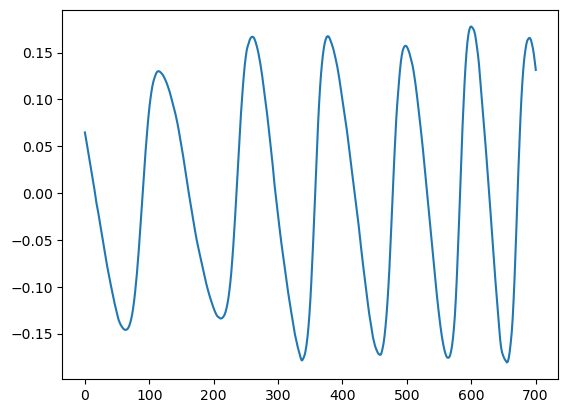

In [74]:
plt.plot(time, radial_v[0])